# Build Calima Dataset

### Find out about if its preasure available.

In [19]:
import pandas as pd
from pathlib import Path
import numpy as np

fp = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\master\master_tfe_2015_2024.parquet")
df = pd.read_parquet(fp).copy()

# Fechas
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["year"] = df["week_start"].dt.year

# Vista rápida
print("shape:", df.shape)
print("range:", df["week_start"].min(), "->", df["week_start"].max())
print(df[["week_start", "PM10", "cap_dust_yellow_plus_week", "calima_dai_flag"]].head(3))

shape: (471, 35)
range: 2015-12-28 00:00:00 -> 2024-12-30 00:00:00
  week_start       PM10  cap_dust_yellow_plus_week calima_dai_flag
0 2015-12-28  41.666667                        NaN            blue
1 2016-01-04  19.142857                        NaN            blue
2 2016-01-11  27.142857                        NaN            blue


In [20]:
# Subset con CAP disponible
cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

print("Rows with CAP available:", len(cap_df))
print(cap_df["cap_dust_yellow_plus_week"].value_counts(dropna=False).sort_index())

cap_pm10_summary = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["PM10"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nPM10 by CAP dust yellow+")
print(cap_pm10_summary)

cap_pm10_q = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["PM10"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nPM10 quantiles by CAP dust yellow+")
print(cap_pm10_q)

Rows with CAP available: 342
cap_dust_yellow_plus_week
0.0    323
1.0     19
Name: count, dtype: int64

PM10 by CAP dust yellow+
                           count    mean  median     std    min     max
cap_dust_yellow_plus_week                                              
0.0                          323   52.64   40.39   46.73   8.29  417.71
1.0                           19  198.08  167.71  138.37  39.71  580.14

PM10 quantiles by CAP dust yellow+
                            0.05   0.25    0.50    0.75    0.95
cap_dust_yellow_plus_week                                      
0.0                        18.44  28.43   40.39   57.24  140.66
1.0                        40.49  93.36  167.71  246.71  395.26


In [21]:
# Fecha límite de cobertura DAI válida
dai_end = pd.Timestamp("2022-03-18")

# Subset DAI válido: solo hasta esa fecha y con flag no nulo
dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

print("Rows with valid DAI coverage:", len(dai_df))
print("DAI valid range:", dai_df["week_start"].min(), "->", dai_df["week_start"].max())
print(dai_df["calima_dai_flag"].value_counts(dropna=False))

dai_pm10_summary = (
    dai_df
    .groupby("calima_dai_flag")["PM10"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

print("\nPM10 by DAI flag (valid period only)")
print(dai_pm10_summary)

dai_pm10_q = (
    dai_df
    .groupby("calima_dai_flag")["PM10"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nPM10 quantiles by DAI flag (valid period only)")
print(dai_pm10_q)

Rows with valid DAI coverage: 325
DAI valid range: 2015-12-28 00:00:00 -> 2022-03-14 00:00:00
calima_dai_flag
blue      277
red        19
green      16
yellow     13
Name: count, dtype: Int64

PM10 by DAI flag (valid period only)
                 count    mean  median     std    min     max
calima_dai_flag                                              
blue               277   37.59   29.71   27.70   6.29  197.14
green               16   68.96   58.29   42.99  30.14  193.43
yellow              13   75.06   49.14   49.78  23.71  158.00
red                 19  164.76  135.61  138.52  21.29  580.14

PM10 quantiles by DAI flag (valid period only)
                  0.05   0.25    0.50    0.75    0.95
calima_dai_flag                                      
blue             11.26  19.71   29.71   45.43   80.69
green            31.43  43.11   58.29   83.48  147.68
red              29.13  94.93  135.61  183.92  395.26
yellow           24.57  38.86   49.14   97.57  156.54


# PM10 muestra una separación fuerte y consistente frente a CAP polvo amarillo+ y frente a DAI válido, por lo que debe considerarse el principal indicador cuantitativo en la construcción de la variable semanal de calima.


In [22]:
# =========================
# TMAX vs CAP
# =========================

cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

print("Rows with CAP available:", len(cap_df))
print(cap_df["cap_dust_yellow_plus_week"].value_counts(dropna=False).sort_index())

cap_tmax_summary = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["tmax_c_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nTMAX by CAP dust yellow+")
print(cap_tmax_summary)

cap_tmax_q = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["tmax_c_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nTMAX quantiles by CAP dust yellow+")
print(cap_tmax_q)

Rows with CAP available: 342
cap_dust_yellow_plus_week
0.0    323
1.0     19
Name: count, dtype: int64

TMAX by CAP dust yellow+
                           count   mean  median   std    min    max
cap_dust_yellow_plus_week                                          
0.0                          323  26.13   26.03  2.70  20.40  36.41
1.0                           19  26.30   24.76  4.37  21.57  36.94

TMAX quantiles by CAP dust yellow+
                            0.05   0.25   0.50   0.75   0.95
cap_dust_yellow_plus_week                                   
0.0                        22.08  24.21  26.03  28.06  30.15
1.0                        21.65  23.54  24.76  28.84  32.87


In [23]:
# =========================
# TMAX vs DAI (valid period only)
# =========================

dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

print("Rows with valid DAI coverage:", len(dai_df))
print("DAI valid range:", dai_df["week_start"].min(), "->", dai_df["week_start"].max())
print(dai_df["calima_dai_flag"].value_counts(dropna=False))

dai_tmax_summary = (
    dai_df
    .groupby("calima_dai_flag")["tmax_c_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

print("\nTMAX by DAI flag (valid period only)")
print(dai_tmax_summary)

dai_tmax_q = (
    dai_df
    .groupby("calima_dai_flag")["tmax_c_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nTMAX quantiles by DAI flag (valid period only)")
print(dai_tmax_q)

Rows with valid DAI coverage: 325
DAI valid range: 2015-12-28 00:00:00 -> 2022-03-14 00:00:00
calima_dai_flag
blue      277
red        19
green      16
yellow     13
Name: count, dtype: Int64

TMAX by DAI flag (valid period only)
                 count   mean  median   std    min    max
calima_dai_flag                                          
red                 19  24.82   24.36  2.85  21.57  31.61
blue               277  25.63   25.40  2.68  20.40  35.13
yellow              13  26.83   27.04  3.35  22.26  32.50
green               16  27.33   29.01  3.31  21.68  32.00

TMAX quantiles by DAI flag (valid period only)
                  0.05   0.25   0.50   0.75   0.95
calima_dai_flag                                   
blue             22.12  23.26  25.40  27.81  30.20
green            22.01  24.10  29.01  29.74  30.90
red              21.65  22.86  24.36  25.24  31.00
yellow           22.76  23.45  27.04  29.09  31.83


# TMAX no separa bien las semanas de calima.

In [24]:
# =========================
# TEMP_MEAN vs CAP
# =========================

cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

cap_temp_summary = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["temp_c_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nTEMP_MEAN by CAP dust yellow+")
print(cap_temp_summary)

cap_temp_q = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["temp_c_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nTEMP_MEAN quantiles by CAP dust yellow+")
print(cap_temp_q)


TEMP_MEAN by CAP dust yellow+
                           count   mean  median   std    min    max
cap_dust_yellow_plus_week                                          
0.0                          323  22.24   22.21  2.57  17.04  30.14
1.0                           19  22.18   20.79  3.72  17.91  30.97

TEMP_MEAN quantiles by CAP dust yellow+
                            0.05   0.25   0.50   0.75   0.95
cap_dust_yellow_plus_week                                   
0.0                        18.26  20.21  22.21  24.32  25.89
1.0                        18.43  19.49  20.79  24.95  28.27


In [25]:
# =========================
# TEMP_MEAN vs DAI (valid period only)
# =========================

dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

dai_temp_summary = (
    dai_df
    .groupby("calima_dai_flag")["temp_c_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

print("\nTEMP_MEAN by DAI flag (valid period only)")
print(dai_temp_summary)

dai_temp_q = (
    dai_df
    .groupby("calima_dai_flag")["temp_c_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nTEMP_MEAN quantiles by DAI flag (valid period only)")
print(dai_temp_q)


TEMP_MEAN by DAI flag (valid period only)
                 count   mean  median   std    min    max
calima_dai_flag                                          
red                 19  20.89   19.94  2.50  17.91  26.46
blue               277  21.76   21.50  2.55  16.99  29.56
yellow              13  22.79   23.56  3.06  18.30  27.93
green               16  23.14   24.65  3.18  17.37  27.60

TEMP_MEAN quantiles by DAI flag (valid period only)
                  0.05   0.25   0.50   0.75   0.95
calima_dai_flag                                   
blue             18.25  19.57  21.50  24.06  25.81
green            17.80  20.03  24.65  25.45  26.23
red              18.43  19.29  19.94  21.18  26.17
yellow           19.12  20.00  23.56  25.01  27.01


In [26]:
print("Overall means:")
print("tmax_c_mean :", round(df["tmax_c_mean"].mean(), 2))
print("temp_c_mean :", round(df["temp_c_mean"].mean(), 2))

Overall means:
tmax_c_mean : 26.02
temp_c_mean : 22.1


# En esta escala semanal y en esta construcción de datos, la temperatura está demasiado mezclada con estacionalidad y otros patrones como para servir como indicador operativo principal.

In [27]:
# =========================
# HUMIDITY vs CAP
# =========================

cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

print("Rows with CAP available:", len(cap_df))
print(cap_df["cap_dust_yellow_plus_week"].value_counts(dropna=False).sort_index())

cap_hum_summary = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["humidity_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nHUMIDITY by CAP dust yellow+")
print(cap_hum_summary)

cap_hum_q = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["humidity_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nHUMIDITY quantiles by CAP dust yellow+")
print(cap_hum_q)

Rows with CAP available: 342
cap_dust_yellow_plus_week
0.0    323
1.0     19
Name: count, dtype: int64

HUMIDITY by CAP dust yellow+
                           count   mean  median    std    min    max
cap_dust_yellow_plus_week                                           
0.0                          323  62.00   63.29   7.05  28.57  77.71
1.0                           19  53.14   52.86  10.55  27.71  70.29

HUMIDITY quantiles by CAP dust yellow+
                            0.05   0.25   0.50   0.75   0.95
cap_dust_yellow_plus_week                                   
0.0                        49.74  59.21  63.29  66.07  71.40
1.0                        38.13  48.14  52.86  59.57  68.49


In [28]:
# =========================
# HUMIDITY vs DAI (valid period only)
# =========================

dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

print("Rows with valid DAI coverage:", len(dai_df))
print("DAI valid range:", dai_df["week_start"].min(), "->", dai_df["week_start"].max())
print(dai_df["calima_dai_flag"].value_counts(dropna=False))

dai_hum_summary = (
    dai_df
    .groupby("calima_dai_flag")["humidity_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

print("\nHUMIDITY by DAI flag (valid period only)")
print(dai_hum_summary)

dai_hum_q = (
    dai_df
    .groupby("calima_dai_flag")["humidity_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nHUMIDITY quantiles by DAI flag (valid period only)")
print(dai_hum_q)

Rows with valid DAI coverage: 325
DAI valid range: 2015-12-28 00:00:00 -> 2022-03-14 00:00:00
calima_dai_flag
blue      277
red        19
green      16
yellow     13
Name: count, dtype: Int64

HUMIDITY by DAI flag (valid period only)
                 count   mean  median   std    min    max
calima_dai_flag                                          
red                 19  55.73   57.14  8.45  36.86  70.29
yellow              13  59.03   61.43  7.86  42.17  66.71
green               16  60.14   63.43  7.89  43.86  68.71
blue               277  62.16   62.71  5.82  35.57  77.71

HUMIDITY quantiles by DAI flag (valid period only)
                  0.05   0.25   0.50   0.75   0.95
calima_dai_flag                                   
blue             51.94  59.71  62.71  65.43  70.49
green            44.09  55.80  63.43  65.93  68.18
red              45.60  49.36  57.14  61.54  66.94
yellow           48.32  52.86  61.43  65.86  66.71


In [29]:
print("\nOverall humidity mean:", round(df["humidity_mean"].mean(), 2))

if len(cap_df) > 0:
    hum_cap0 = cap_df.loc[cap_df["cap_dust_yellow_plus_week"] == 0, "humidity_mean"].mean()
    hum_cap1 = cap_df.loc[cap_df["cap_dust_yellow_plus_week"] == 1, "humidity_mean"].mean()
    print("Humidity mean | CAP=0:", round(hum_cap0, 2))
    print("Humidity mean | CAP=1:", round(hum_cap1, 2))
    print("Difference CAP1 - CAP0:", round(hum_cap1 - hum_cap0, 2))


Overall humidity mean: 61.46
Humidity mean | CAP=0: 62.0
Humidity mean | CAP=1: 53.14
Difference CAP1 - CAP0: -8.87


# humidity_mean entra como variable útil de apoyo en la definición de calima semanal.

In [30]:
# =========================
# LOW_VIS_ANY_WEEK vs CAP
# =========================

cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

print("Rows with CAP available:", len(cap_df))
print(cap_df["cap_dust_yellow_plus_week"].value_counts(dropna=False).sort_index())

cap_lowvis_tab = pd.crosstab(
    cap_df["low_vis_any_week"],
    cap_df["cap_dust_yellow_plus_week"],
    margins=True
)

print("\nCrosstab: low_vis_any_week vs CAP dust yellow+")
print(cap_lowvis_tab)

cap_lowvis_rate = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["low_vis_any_week"]
    .mean()
    .round(3)
)

print("\nShare of weeks with low_vis_any_week=1 by CAP")
print(cap_lowvis_rate)

Rows with CAP available: 342
cap_dust_yellow_plus_week
0.0    323
1.0     19
Name: count, dtype: int64

Crosstab: low_vis_any_week vs CAP dust yellow+
cap_dust_yellow_plus_week  0.0  1.0  All
low_vis_any_week                        
0                          250    2  252
1                           73   17   90
All                        323   19  342

Share of weeks with low_vis_any_week=1 by CAP
cap_dust_yellow_plus_week
0.0    0.226
1.0    0.895
Name: low_vis_any_week, dtype: float64


In [31]:
# =========================
# LOW_VIS_ANY_WEEK vs DAI (valid period only)
# =========================

dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

print("Rows with valid DAI coverage:", len(dai_df))
print(dai_df["calima_dai_flag"].value_counts(dropna=False))

dai_lowvis_tab = pd.crosstab(
    dai_df["low_vis_any_week"],
    dai_df["calima_dai_flag"],
    margins=True
)

print("\nCrosstab: low_vis_any_week vs DAI")
print(dai_lowvis_tab)

dai_lowvis_rate = (
    dai_df
    .groupby("calima_dai_flag")["low_vis_any_week"]
    .mean()
    .round(3)
)

print("\nShare of weeks with low_vis_any_week=1 by DAI")
print(dai_lowvis_rate)

Rows with valid DAI coverage: 325
calima_dai_flag
blue      277
red        19
green      16
yellow     13
Name: count, dtype: Int64

Crosstab: low_vis_any_week vs DAI
calima_dai_flag   blue  green  red  yellow  All
low_vis_any_week                               
0                  224      3    3       4  234
1                   53     13   16       9   91
All                277     16   19      13  325

Share of weeks with low_vis_any_week=1 by DAI
calima_dai_flag
blue      0.191
green     0.812
red       0.842
yellow    0.692
Name: low_vis_any_week, dtype: float64


# low_vis_any_week entra clarísimamente.

In [32]:
# =========================
# PRESSURE vs CAP
# =========================

cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

cap_pres_summary = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["pressure_hpa_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nPRESSURE by CAP dust yellow+")
print(cap_pres_summary)

cap_pres_q = (
    cap_df
    .groupby("cap_dust_yellow_plus_week")["pressure_hpa_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nPRESSURE quantiles by CAP dust yellow+")
print(cap_pres_q)


PRESSURE by CAP dust yellow+
                           count     mean   median   std      min      max
cap_dust_yellow_plus_week                                                 
0.0                          323  1009.51  1009.02  2.73  1002.95  1017.59
1.0                           19  1010.93  1010.66  3.49  1005.44  1017.13

PRESSURE quantiles by CAP dust yellow+
                              0.05     0.25     0.50     0.75     0.95
cap_dust_yellow_plus_week                                             
0.0                        1005.71  1007.63  1009.02  1010.82  1014.97
1.0                        1005.99  1008.73  1010.66  1013.42  1016.75


In [33]:
# =========================
# PRESSURE vs DAI (valid period only)
# =========================

dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

dai_pres_summary = (
    dai_df
    .groupby("calima_dai_flag")["pressure_hpa_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

print("\nPRESSURE by DAI flag (valid period only)")
print(dai_pres_summary)

dai_pres_q = (
    dai_df
    .groupby("calima_dai_flag")["pressure_hpa_mean"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

print("\nPRESSURE quantiles by DAI flag (valid period only)")
print(dai_pres_q)


PRESSURE by DAI flag (valid period only)
                 count     mean   median   std      min      max
calima_dai_flag                                                 
green               16  1008.57  1008.44  2.22  1004.83  1013.19
yellow              13  1009.17  1009.10  2.98  1003.66  1016.42
blue               277  1009.99  1009.50  3.08  1000.54  1018.81
red                 19  1011.14  1011.21  2.66  1006.04  1015.15

PRESSURE quantiles by DAI flag (valid period only)
                    0.05     0.25     0.50     0.75     0.95
calima_dai_flag                                             
blue             1005.86  1007.76  1009.50  1011.68  1015.84
green            1005.84  1007.14  1008.44  1009.59  1012.66
red              1006.90  1009.22  1011.21  1013.34  1014.46
yellow           1005.42  1007.65  1009.10  1010.06  1013.77


1. crear calima_score_v1
2. crear calima_level_v1
3. compararlo con CAP
4. compararlo con DAI válido
### He usado justo las variables que mejor han funcionado:
- PM10
- humidity_mean
- low_vis_any_week

In [34]:
df = pd.read_parquet(fp).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# =========================
# THRESHOLDS
# =========================
# Global thresholds for a first transparent version

pm10_p90 = df["PM10"].quantile(0.90)
pm10_p95 = df["PM10"].quantile(0.95)
hum_p25  = df["humidity_mean"].quantile(0.25)

print("Thresholds used:")
print("PM10 p90 =", round(pm10_p90, 2))
print("PM10 p95 =", round(pm10_p95, 2))
print("Humidity p25 =", round(hum_p25, 2))

# =========================
# SCORE COMPONENTS
# =========================

df["pm10_p90_flag"] = (df["PM10"] >= pm10_p90).astype(int)
df["pm10_p95_flag"] = (df["PM10"] >= pm10_p95).astype(int)
df["hum_low_flag"]  = (df["humidity_mean"] <= hum_p25).astype(int)
df["low_vis_flag"]  = df["low_vis_any_week"].fillna(0).astype(int)

# Score:
# +2 if PM10 >= p90
# +1 extra if PM10 >= p95
# +1 if humidity <= p25
# +1 if low visibility present

df["calima_score_v1"] = (
    2 * df["pm10_p90_flag"]
    + 1 * df["pm10_p95_flag"]
    + 1 * df["hum_low_flag"]
    + 1 * df["low_vis_flag"]
)

# =========================
# LEVELS
# =========================

def score_to_level(score: int) -> str:
    if score <= 1:
        return "no_calima"
    elif score == 2:
        return "possible"
    elif score == 3:
        return "probable"
    else:
        return "intense"

df["calima_level_v1"] = df["calima_score_v1"].apply(score_to_level)

print("\nScore distribution:")
print(df["calima_score_v1"].value_counts().sort_index())

print("\nLevel distribution:")
print(df["calima_level_v1"].value_counts())

Thresholds used:
PM10 p90 = 97.57
PM10 p95 = 152.64
Humidity p25 = 58.71

Score distribution:
calima_score_v1
0    276
1    124
2     24
3      8
4     26
5     13
Name: count, dtype: int64

Level distribution:
calima_level_v1
no_calima    400
intense       39
possible      24
probable       8
Name: count, dtype: int64


In [35]:
cols = [
    "week_start",
    "PM10",
    "humidity_mean",
    "low_vis_any_week",
    "cap_dust_yellow_plus_week",
    "calima_dai_flag",
    "calima_score_v1",
    "calima_level_v1",
]

top_score = (
    df[cols]
    .sort_values(["calima_score_v1", "PM10"], ascending=[False, False])
    .head(20)
)

print(top_score.to_string(index=False))

week_start       PM10  humidity_mean  low_vis_any_week  cap_dust_yellow_plus_week calima_dai_flag  calima_score_v1 calima_level_v1
2022-01-10 580.142857      49.714286                 1                        1.0             red                5         intense
2023-12-11 417.714286      42.200000                 1                        0.0            blue                5         intense
2021-02-15 374.714286      47.571429                 1                        1.0             red                5         intense
2024-12-16 348.428571      48.714286                 1                        1.0            blue                5         intense
2023-10-02 252.285714      39.285714                 1                        1.0            blue                5         intense
2024-01-22 241.142857      39.571429                 1                        1.0            blue                5         intense
2024-01-29 224.857143      37.142857                 1                        0.0  

In [36]:
cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

print("Rows with CAP available:", len(cap_df))
print(cap_df["cap_dust_yellow_plus_week"].value_counts(dropna=False).sort_index())

print("\nMean calima_score_v1 by CAP")
print(
    cap_df.groupby("cap_dust_yellow_plus_week")["calima_score_v1"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nCrosstab: calima_level_v1 vs CAP dust yellow+")
print(
    pd.crosstab(
        cap_df["calima_level_v1"],
        cap_df["cap_dust_yellow_plus_week"],
        margins=True
    )
)

print("\nRow-normalized crosstab: calima_level_v1 vs CAP dust yellow+")
print(
    pd.crosstab(
        cap_df["calima_level_v1"],
        cap_df["cap_dust_yellow_plus_week"],
        normalize="index"
    ).round(3)
)

print("\nColumn-normalized crosstab: calima_level_v1 vs CAP dust yellow+")
print(
    pd.crosstab(
        cap_df["calima_level_v1"],
        cap_df["cap_dust_yellow_plus_week"],
        normalize="columns"
    ).round(3)
)

Rows with CAP available: 342
cap_dust_yellow_plus_week
0.0    323
1.0     19
Name: count, dtype: int64

Mean calima_score_v1 by CAP
                           count  mean  median  min  max
cap_dust_yellow_plus_week                               
0.0                          323  0.69     0.0    0    5
1.0                           19  3.63     4.0    1    5

Crosstab: calima_level_v1 vs CAP dust yellow+
cap_dust_yellow_plus_week  0.0  1.0  All
calima_level_v1                         
intense                     23   13   36
no_calima                  281    4  285
possible                    12    1   13
probable                     7    1    8
All                        323   19  342

Row-normalized crosstab: calima_level_v1 vs CAP dust yellow+
cap_dust_yellow_plus_week    0.0    1.0
calima_level_v1                        
intense                    0.639  0.361
no_calima                  0.986  0.014
possible                   0.923  0.077
probable                   0.875  0.125

Col

In [37]:
print("\nCAP=1 but low score (<=2)")
print(
    cap_df.loc[
        (cap_df["cap_dust_yellow_plus_week"] == 1) &
        (cap_df["calima_score_v1"] <= 2),
        ["week_start", "PM10", "humidity_mean", "low_vis_any_week",
         "cap_dust_yellow_plus_week", "calima_dai_flag",
         "calima_score_v1", "calima_level_v1"]
    ]
    .sort_values("week_start")
    .to_string(index=False)
)

print("\nCAP=0 but high score (>=4)")
print(
    cap_df.loc[
        (cap_df["cap_dust_yellow_plus_week"] == 0) &
        (cap_df["calima_score_v1"] >= 4),
        ["week_start", "PM10", "humidity_mean", "low_vis_any_week",
         "cap_dust_yellow_plus_week", "calima_dai_flag",
         "calima_score_v1", "calima_level_v1"]
    ]
    .sort_values("PM10", ascending=False)
    .head(20)
    .to_string(index=False)
)


CAP=1 but low score (<=2)
week_start      PM10  humidity_mean  low_vis_any_week  cap_dust_yellow_plus_week calima_dai_flag  calima_score_v1 calima_level_v1
2021-08-09 39.714286      65.428571                 1                        1.0            blue                1       no_calima
2022-01-03 63.142857      52.285714                 0                        1.0            blue                1       no_calima
2022-04-11 74.428571      58.428571                 0                        1.0            blue                1       no_calima
2023-03-27 68.857143      27.714286                 1                        1.0            blue                2        possible
2023-09-25 40.571429      68.285714                 1                        1.0            blue                1       no_calima

CAP=0 but high score (>=4)
week_start       PM10  humidity_mean  low_vis_any_week  cap_dust_yellow_plus_week calima_dai_flag  calima_score_v1 calima_level_v1
2023-12-11 417.714286      42.2000

In [39]:
dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

print("Rows with valid DAI coverage:", len(dai_df))
print("DAI valid range:", dai_df["week_start"].min(), "->", dai_df["week_start"].max())
print(dai_df["calima_dai_flag"].value_counts(dropna=False))

print("\nMean calima_score_v1 by DAI")
print(
    dai_df.groupby("calima_dai_flag")["calima_score_v1"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nCrosstab: calima_level_v1 vs DAI")
print(
    pd.crosstab(
        dai_df["calima_level_v1"],
        dai_df["calima_dai_flag"],
        margins=True
    )
)

print("\nRow-normalized crosstab: calima_level_v1 vs DAI")
print(
    pd.crosstab(
        dai_df["calima_level_v1"],
        dai_df["calima_dai_flag"],
        normalize="index"
    ).round(3)
)

print("\nColumn-normalized crosstab: calima_level_v1 vs DAI")
print(
    pd.crosstab(
        dai_df["calima_level_v1"],
        dai_df["calima_dai_flag"],
        normalize="columns"
    ).round(3)
)

Rows with valid DAI coverage: 325
DAI valid range: 2015-12-28 00:00:00 -> 2022-03-14 00:00:00
calima_dai_flag
blue      277
red        19
green      16
yellow     13
Name: count, dtype: Int64

Mean calima_score_v1 by DAI
                 count  mean  median  min  max
calima_dai_flag                               
blue               277  0.48     0.0    0    5
green               16  1.50     1.0    0    4
red                 19  3.21     4.0    0    5
yellow              13  1.92     1.0    0    4

Crosstab: calima_level_v1 vs DAI
calima_dai_flag  blue  green  red  yellow  All
calima_level_v1                               
intense             7      2   12       4   25
no_calima         257     10    5       7  279
possible           11      4    0       2   17
probable            2      0    2       0    4
All               277     16   19      13  325

Row-normalized crosstab: calima_level_v1 vs DAI
calima_dai_flag   blue  green    red  yellow
calima_level_v1                         

In [38]:
calima_cols = [
    "week_start",
    "PM10",
    "PM2.5",
    "humidity_mean",
    "pressure_hpa_mean",
    "low_vis_any_week",
    "cap_dust_yellow_plus_week",
    "cap_dust_level_max_week",
    "calima_dai_flag",
    "pm10_p90_flag",
    "pm10_p95_flag",
    "hum_low_flag",
    "low_vis_flag",
    "calima_score_v1",
    "calima_level_v1",
]

calima_df = df[calima_cols].copy()

print("\ncalima_df shape:", calima_df.shape)
print(calima_df.head(10).to_string(index=False))


calima_df shape: (471, 15)
week_start      PM10     PM2.5  humidity_mean  pressure_hpa_mean  low_vis_any_week  cap_dust_yellow_plus_week  cap_dust_level_max_week calima_dai_flag  pm10_p90_flag  pm10_p95_flag  hum_low_flag  low_vis_flag  calima_score_v1 calima_level_v1
2015-12-28 41.666667 20.000000      67.333333        1016.700000                 0                        NaN                      NaN            blue              0              0             0             0                0       no_calima
2016-01-04 19.142857  9.571429      65.428571        1013.242857                 0                        NaN                      NaN            blue              0              0             0             0                0       no_calima
2016-01-11 27.142857 12.714286      57.571429        1011.921429                 0                        NaN                      NaN            blue              0              0             1             0                1       no_calima
2016

# Código para una v2 con presión suave

In [43]:
# =========================
# LOAD
# =========================
fp = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\master\master_tfe_2015_2024.parquet")
df = pd.read_parquet(fp).copy()
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# =========================
# THRESHOLDS
# =========================

pm10_p90 = df["PM10"].quantile(0.90)
pm10_p95 = df["PM10"].quantile(0.95)
hum_p25  = df["humidity_mean"].quantile(0.25)
pres_p75 = df["pressure_hpa_mean"].quantile(0.75)

print("Thresholds used:")
print("PM10 p90 =", round(pm10_p90, 2))
print("PM10 p95 =", round(pm10_p95, 2))
print("Humidity p25 =", round(hum_p25, 2))
print("Pressure p75 =", round(pres_p75, 2))

# =========================
# FLAGS
# =========================

df["pm10_p90_flag"]      = (df["PM10"] >= pm10_p90).astype(int)
df["pm10_p95_flag"]      = (df["PM10"] >= pm10_p95).astype(int)
df["hum_low_flag"]       = (df["humidity_mean"] <= hum_p25).astype(int)
df["low_vis_flag"]       = df["low_vis_any_week"].fillna(0).astype(int)
df["pressure_high_flag"] = (df["pressure_hpa_mean"] >= pres_p75).astype(int)

# =========================
# SCORE V2
# =========================
# PM10 p90 = +1
# PM10 p95 extra = +1
# low humidity = +1
# low visibility = +1
# high pressure = +0.5 (soft influence)

df["calima_score_v2"] = (
    1.0 * df["pm10_p90_flag"]
    + 1.0 * df["pm10_p95_flag"]
    + 1.0 * df["hum_low_flag"]
    + 1.0 * df["low_vis_flag"]
    + 0.5 * df["pressure_high_flag"]
)

def score_to_level_v2(score: float) -> str:
    if score < 1:
        return "no_calima"
    elif score < 2:
        return "possible"
    elif score < 3:
        return "probable"
    else:
        return "intense"

df["calima_level_v2"] = df["calima_score_v2"].apply(score_to_level_v2)

print("\nScore v2 distribution:")
print(df["calima_score_v2"].value_counts().sort_index())

print("\nLevel v2 distribution:")
print(df["calima_level_v2"].value_counts())

Thresholds used:
PM10 p90 = 97.57
PM10 p95 = 152.64
Humidity p25 = 58.71
Pressure p75 = 1011.28

Score v2 distribution:
calima_score_v2
0.0    221
0.5     55
1.0     88
1.5     37
2.0     26
2.5      5
3.0     13
3.5     13
4.0      5
4.5      8
Name: count, dtype: int64

Level v2 distribution:
calima_level_v2
no_calima    276
possible     125
intense       39
probable      31
Name: count, dtype: int64


In [44]:
cap_df = df[df["cap_dust_yellow_plus_week"].notna()].copy()

print("\nMean calima_score_v2 by CAP")
print(
    cap_df.groupby("cap_dust_yellow_plus_week")["calima_score_v2"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nCrosstab: calima_level_v2 vs CAP dust yellow+")
print(
    pd.crosstab(
        cap_df["calima_level_v2"],
        cap_df["cap_dust_yellow_plus_week"],
        margins=True
    )
)

print("\nColumn-normalized crosstab: calima_level_v2 vs CAP dust yellow+")
print(
    pd.crosstab(
        cap_df["calima_level_v2"],
        cap_df["cap_dust_yellow_plus_week"],
        normalize="columns"
    ).round(3)
)


Mean calima_score_v2 by CAP
                           count  mean  median  min  max
cap_dust_yellow_plus_week                               
0.0                          323  0.71     0.0  0.0  4.5
1.0                           19  3.11     3.5  1.0  4.5

Crosstab: calima_level_v2 vs CAP dust yellow+
cap_dust_yellow_plus_week  0.0  1.0  All
calima_level_v2                         
intense                     23   13   36
no_calima                  199    0  199
possible                    83    4   87
probable                    18    2   20
All                        323   19  342

Column-normalized crosstab: calima_level_v2 vs CAP dust yellow+
cap_dust_yellow_plus_week    0.0    1.0
calima_level_v2                        
intense                    0.071  0.684
no_calima                  0.616  0.000
possible                   0.257  0.211
probable                   0.056  0.105


In [45]:
dai_end = pd.Timestamp("2022-03-18")

dai_df = df[
    (df["week_start"] <= dai_end) &
    (df["calima_dai_flag"].notna())
].copy()

print("\nMean calima_score_v2 by DAI")
print(
    dai_df.groupby("calima_dai_flag")["calima_score_v2"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nCrosstab: calima_level_v2 vs DAI")
print(
    pd.crosstab(
        dai_df["calima_level_v2"],
        dai_df["calima_dai_flag"],
        margins=True
    )
)

print("\nColumn-normalized crosstab: calima_level_v2 vs DAI")
print(
    pd.crosstab(
        dai_df["calima_level_v2"],
        dai_df["calima_dai_flag"],
        normalize="columns"
    ).round(3)
)


Mean calima_score_v2 by DAI
                 count  mean  median  min  max
calima_dai_flag                               
blue               277  0.58     0.0  0.0  4.5
green               16  1.44     1.0  0.0  3.0
red                 19  2.71     3.5  0.0  4.5
yellow              13  1.69     1.0  0.0  3.5

Crosstab: calima_level_v2 vs DAI
calima_dai_flag  blue  green  red  yellow  All
calima_level_v2                               
intense             7      2   12       4   25
no_calima         182      2    2       2  188
possible           76      8    3       5   92
probable           12      4    2       2   20
All               277     16   19      13  325

Column-normalized crosstab: calima_level_v2 vs DAI
calima_dai_flag   blue  green    red  yellow
calima_level_v2                             
intense          0.025  0.125  0.632   0.308
no_calima        0.657  0.125  0.105   0.154
possible         0.274  0.500  0.158   0.385
probable         0.043  0.250  0.105   0.154


# calima_proxy_score_v2:
# heuristic weekly calima proxy based on PM10, low humidity, low visibility,
# and weak support from relatively high pressure.
# CAP and DAI are used only as external reference checks, not as defining inputs.

In [46]:
from pathlib import Path
import pandas as pd
import numpy as np

# =========================================================
# LOAD MASTER
# =========================================================

fp = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\master\master_tfe_2015_2024.parquet")
df = pd.read_parquet(fp).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# =========================================================
# THRESHOLDS
# =========================================================
# Heuristic thresholds computed on the full Tenerife weekly series

pm10_p90 = df["PM10"].quantile(0.90)
pm10_p95 = df["PM10"].quantile(0.95)
hum_p25  = df["humidity_mean"].quantile(0.25)
pres_p75 = df["pressure_hpa_mean"].quantile(0.75)

print("Thresholds used:")
print("PM10 p90 =", round(pm10_p90, 2))
print("PM10 p95 =", round(pm10_p95, 2))
print("Humidity p25 =", round(hum_p25, 2))
print("Pressure p75 =", round(pres_p75, 2))

# =========================================================
# COMPONENT FLAGS
# =========================================================

df["pm10_p90_flag"] = (df["PM10"] >= pm10_p90).astype(int)
df["pm10_p95_flag"] = (df["PM10"] >= pm10_p95).astype(int)
df["hum_low_flag"] = (df["humidity_mean"] <= hum_p25).astype(int)
df["low_vis_flag"] = df["low_vis_any_week"].fillna(0).astype(int)
df["pressure_high_flag"] = (df["pressure_hpa_mean"] >= pres_p75).astype(int)

# =========================================================
# HEURISTIC CALIMA PROXY SCORE (V2)
# =========================================================
# Weights:
# +1.0 if PM10 >= p90
# +1.0 extra if PM10 >= p95
# +1.0 if humidity_mean <= p25
# +1.0 if low_vis_any_week == 1
# +0.5 if pressure_hpa_mean >= p75

df["calima_proxy_score_v2"] = (
    1.0 * df["pm10_p90_flag"]
    + 1.0 * df["pm10_p95_flag"]
    + 1.0 * df["hum_low_flag"]
    + 1.0 * df["low_vis_flag"]
    + 0.5 * df["pressure_high_flag"]
)

def score_to_level_v2(score: float) -> str:
    if score < 1:
        return "no_calima"
    elif score < 2:
        return "possible"
    elif score < 3:
        return "probable"
    else:
        return "intense"

df["calima_proxy_level_v2"] = df["calima_proxy_score_v2"].apply(score_to_level_v2)

# =========================================================
# OUTPUT DATASET
# =========================================================

keep_cols = [
    "week_start",
    "deaths_week",
    "PM10",
    "PM2.5",
    "humidity_mean",
    "pressure_hpa_mean",
    "low_vis_any_week",
    "cap_dust_yellow_plus_week",
    "cap_dust_level_max_week",
    "calima_dai_flag",
    "pm10_p90_flag",
    "pm10_p95_flag",
    "hum_low_flag",
    "low_vis_flag",
    "pressure_high_flag",
    "calima_proxy_score_v2",
    "calima_proxy_level_v2",
]

calima_df = df[keep_cols].copy()

out_dir = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\calima")
out_dir.mkdir(parents=True, exist_ok=True)

out_parquet = out_dir / "calima_proxy_weekly_tfe_2015_2024_v2.parquet"
out_csv = out_dir / "calima_proxy_weekly_tfe_2015_2024_v2.csv"

calima_df.to_parquet(out_parquet, index=False)
calima_df.to_csv(out_csv, index=False)

print("\nSaved:")
print(out_parquet)
print(out_csv)

print("\nShape:", calima_df.shape)
print("\nScore distribution:")
print(calima_df["calima_proxy_score_v2"].value_counts().sort_index())

print("\nLevel distribution:")
print(calima_df["calima_proxy_level_v2"].value_counts())

print("\nPreview:")
print(calima_df.head(10).to_string(index=False))

Thresholds used:
PM10 p90 = 97.57
PM10 p95 = 152.64
Humidity p25 = 58.71
Pressure p75 = 1011.28

Saved:
C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2015_2024_v2.parquet
C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2015_2024_v2.csv

Shape: (471, 17)

Score distribution:
calima_proxy_score_v2
0.0    221
0.5     55
1.0     88
1.5     37
2.0     26
2.5      5
3.0     13
3.5     13
4.0      5
4.5      8
Name: count, dtype: int64

Level distribution:
calima_proxy_level_v2
no_calima    276
possible     125
intense       39
probable      31
Name: count, dtype: int64

Preview:
week_start  deaths_week      PM10     PM2.5  humidity_mean  pressure_hpa_mean  low_vis_any_week  cap_dust_yellow_plus_week  cap_dust_level_max_week calima_dai_flag  pm10_p90_flag  pm10_p95_flag  hum_low_flag  low_vis_flag  pressure_high_flag  calima_proxy_score_v2 calima_proxy_level_v2
2015-12-28        129.0 41.666667 20.

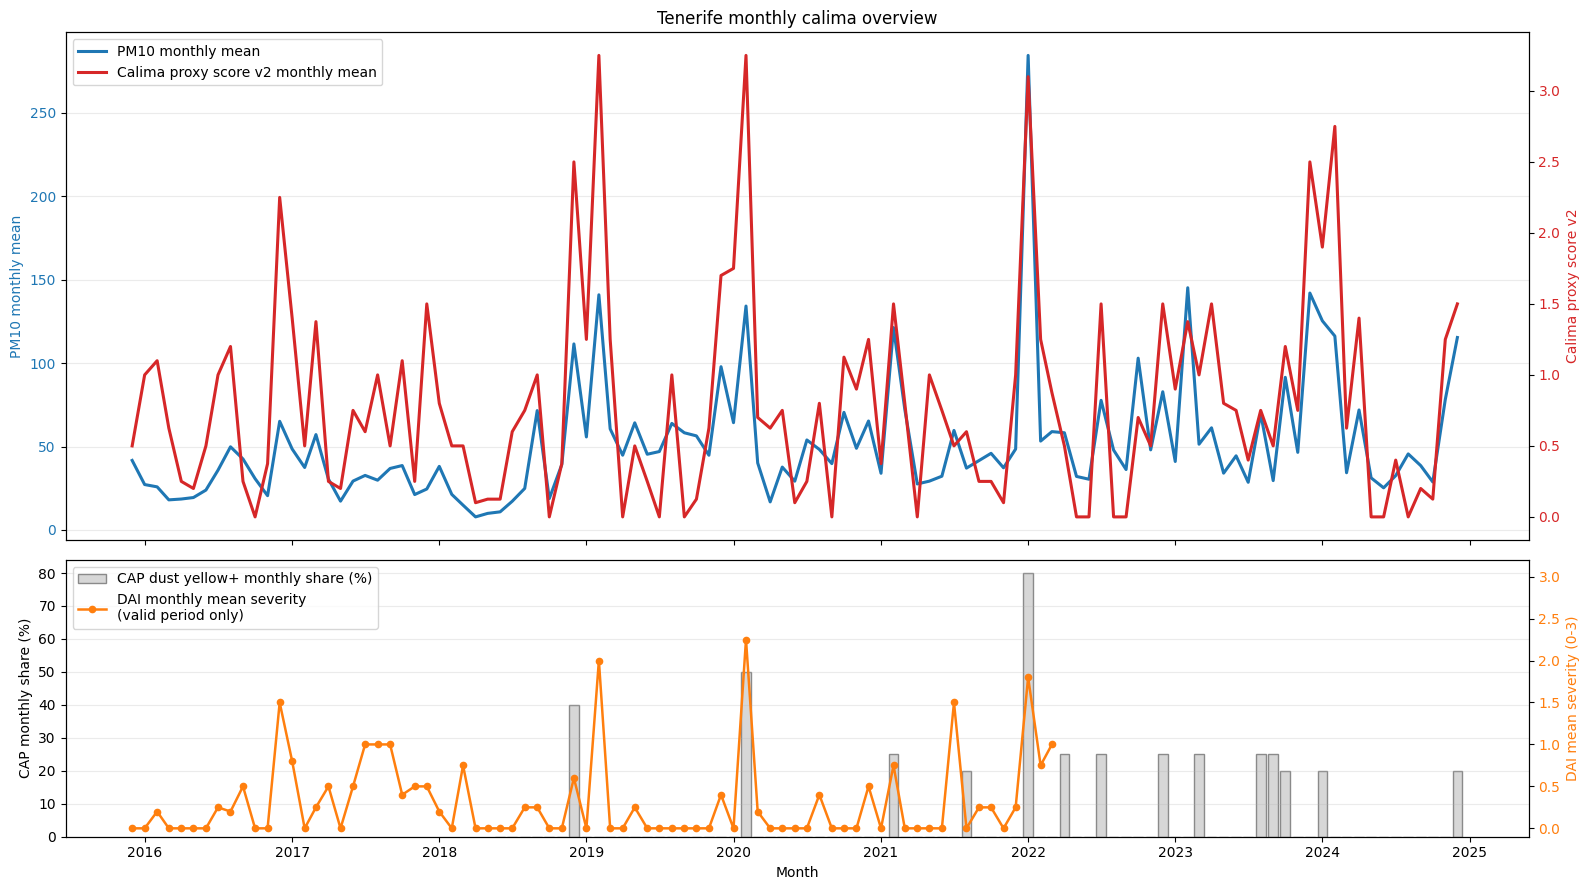

Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\calima\tfe_monthly_calima_overview_v2.png


In [48]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# LOAD
# =========================================================

fp = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2015_2024_v2.parquet")
df = pd.read_parquet(fp).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# =========================================================
# DAI valid period only
# =========================================================

dai_end = pd.Timestamp("2022-03-18")
df["calima_dai_flag_valid"] = df["calima_dai_flag"]
df.loc[df["week_start"] > dai_end, "calima_dai_flag_valid"] = pd.NA

dai_map = {
    "blue": 0,
    "green": 1,
    "yellow": 2,
    "red": 3,
}
df["dai_severity"] = df["calima_dai_flag_valid"].map(dai_map)

# =========================================================
# MONTHLY AGGREGATION
# =========================================================

df["month"] = df["week_start"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby("month", as_index=False)
      .agg(
          pm10_mean_month=("PM10", "mean"),
          calima_score_mean_month=("calima_proxy_score_v2", "mean"),
          cap_share_month=("cap_dust_yellow_plus_week", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
          dai_mean_month=("dai_severity", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
          n_weeks=("week_start", "size")
      )
)

# Optional: make CAP bars a bit more visible without changing their values
monthly["cap_share_pct"] = monthly["cap_share_month"] * 100

# =========================================================
# PLOT
# =========================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2]}
)

# -------------------------
# TOP PANEL: PM10 + proxy
# -------------------------

ax1.plot(
    monthly["month"],
    monthly["pm10_mean_month"],
    color="tab:blue",
    linewidth=2.2,
    label="PM10 monthly mean"
)

ax1.set_ylabel("PM10 monthly mean", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, axis="y", alpha=0.25)

ax1b = ax1.twinx()
ax1b.plot(
    monthly["month"],
    monthly["calima_score_mean_month"],
    color="tab:red",
    linewidth=2.2,
    label="Calima proxy score v2 monthly mean"
)
ax1b.set_ylabel("Calima proxy score v2", color="tab:red")
ax1b.tick_params(axis="y", labelcolor="tab:red")

# Combined legend for top panel
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

ax1.set_title("Tenerife monthly calima overview")

# -------------------------
# BOTTOM PANEL: CAP + DAI
# -------------------------

# CAP as percentage bars for visibility
ax2.bar(
    monthly["month"],
    monthly["cap_share_pct"],
    width=24,
    color="lightgray",
    edgecolor="gray",
    alpha=0.9,
    label="CAP dust yellow+ monthly share (%)"
)

ax2.set_ylabel("CAP monthly share (%)")
ax2.grid(True, axis="y", alpha=0.25)

ax2b = ax2.twinx()
ax2b.plot(
    monthly["month"],
    monthly["dai_mean_month"],
    color="tab:orange",
    marker="o",
    linewidth=1.8,
    markersize=4.5,
    label="DAI monthly mean severity\n(valid period only)"
)

ax2b.set_ylabel("DAI mean severity (0-3)", color="tab:orange")
ax2b.tick_params(axis="y", labelcolor="tab:orange")
ax2b.set_ylim(-0.1, 3.2)

# Combined legend for bottom panel
h3, l3 = ax2.get_legend_handles_labels()
h4, l4 = ax2b.get_legend_handles_labels()
ax2.legend(h3 + h4, l3 + l4, loc="upper left")

# -------------------------
# X axis formatting
# -------------------------

ax2.set_xlabel("Month")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

out_dir = Path(r"C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\calima")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_monthly_calima_overview_v2.png"
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp)

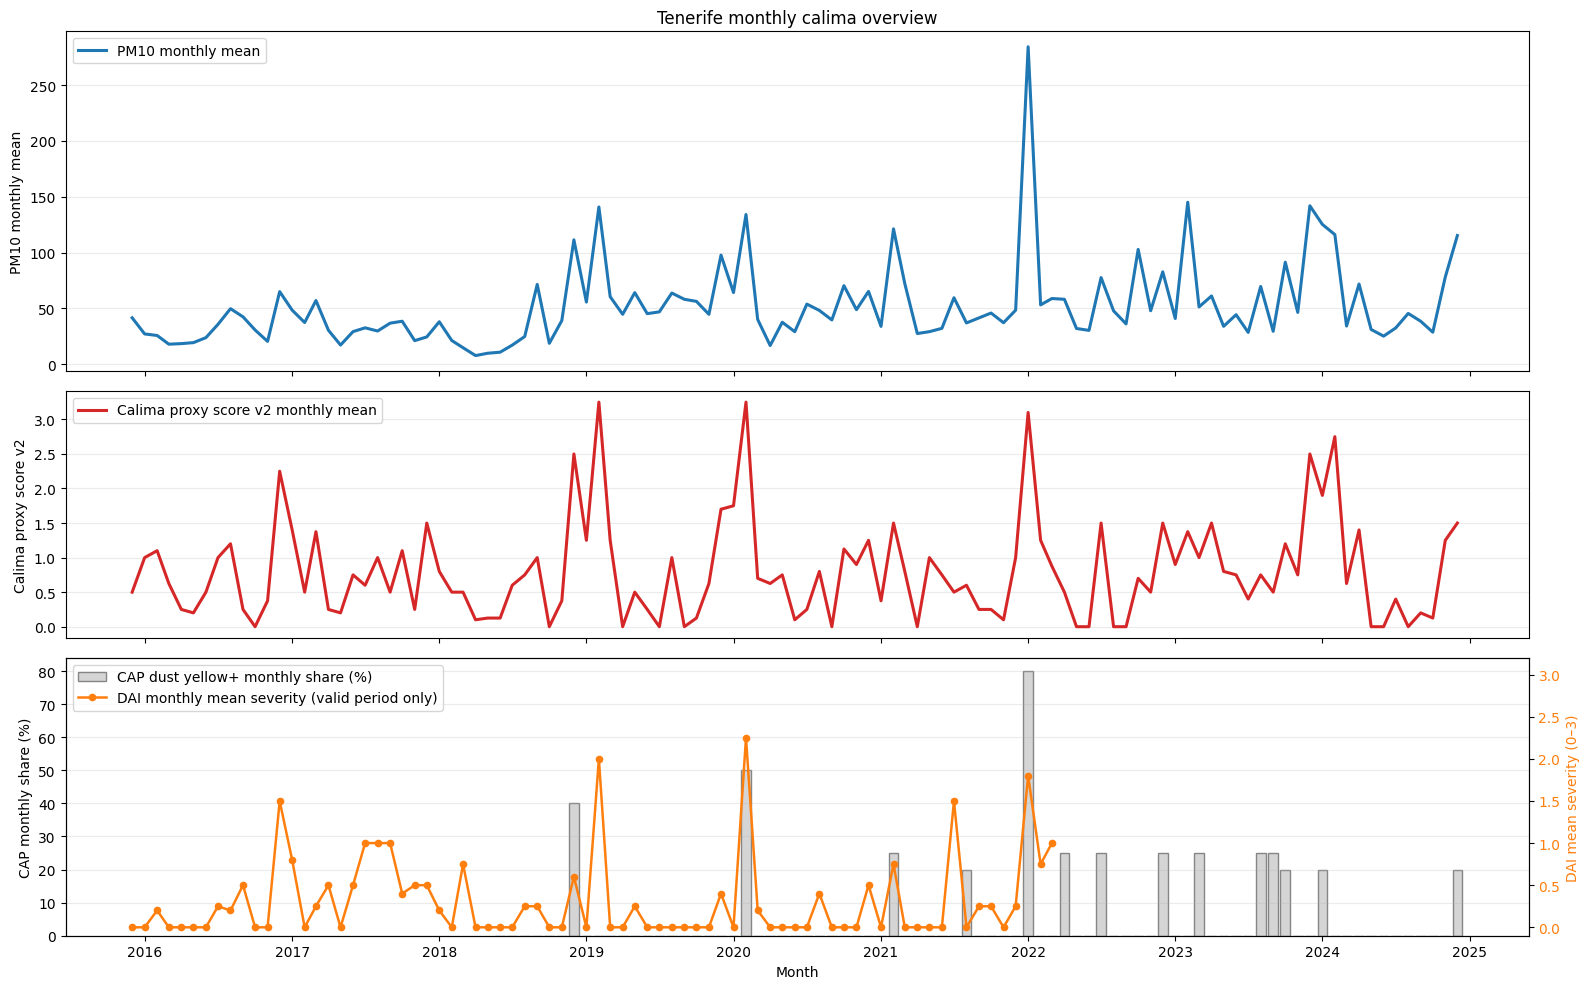

Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\calima\tfe_monthly_calima_overview_3panels_v1.png


In [49]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# LOAD
# =========================================================

fp = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2015_2024_v2.parquet")
df = pd.read_parquet(fp).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# =========================================================
# DAI valid period only
# =========================================================

dai_end = pd.Timestamp("2022-03-18")
df["calima_dai_flag_valid"] = df["calima_dai_flag"]
df.loc[df["week_start"] > dai_end, "calima_dai_flag_valid"] = pd.NA

dai_map = {
    "blue": 0,
    "green": 1,
    "yellow": 2,
    "red": 3,
}
df["dai_severity"] = df["calima_dai_flag_valid"].map(dai_map)

# =========================================================
# MONTHLY AGGREGATION
# =========================================================

df["month"] = df["week_start"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby("month", as_index=False)
      .agg(
          pm10_mean_month=("PM10", "mean"),
          calima_score_mean_month=("calima_proxy_score_v2", "mean"),
          cap_share_month=("cap_dust_yellow_plus_week", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
          dai_mean_month=("dai_severity", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
          n_weeks=("week_start", "size")
      )
)

monthly["cap_share_pct"] = monthly["cap_share_month"] * 100

# =========================================================
# PLOT: 3 PANELS
# =========================================================

fig, axes = plt.subplots(
    3, 1, figsize=(16, 10), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.6, 1.8]}
)

ax1, ax2, ax3 = axes

# -------------------------
# PANEL 1: PM10
# -------------------------
ax1.plot(
    monthly["month"],
    monthly["pm10_mean_month"],
    color="tab:blue",
    linewidth=2.2,
    label="PM10 monthly mean"
)
ax1.set_ylabel("PM10 monthly mean")
ax1.set_title("Tenerife monthly calima overview")
ax1.grid(True, axis="y", alpha=0.25)
ax1.legend(loc="upper left")

# -------------------------
# PANEL 2: Calima proxy score
# -------------------------
ax2.plot(
    monthly["month"],
    monthly["calima_score_mean_month"],
    color="tab:red",
    linewidth=2.2,
    label="Calima proxy score v2 monthly mean"
)
ax2.set_ylabel("Calima proxy score v2")
ax2.grid(True, axis="y", alpha=0.25)
ax2.legend(loc="upper left")

# -------------------------
# PANEL 3: CAP + DAI
# -------------------------
bars = ax3.bar(
    monthly["month"],
    monthly["cap_share_pct"],
    width=24,
    color="lightgray",
    edgecolor="gray",
    alpha=0.95,
    label="CAP dust yellow+ monthly share (%)"
)
ax3.set_ylabel("CAP monthly share (%)")
ax3.grid(True, axis="y", alpha=0.25)

ax3b = ax3.twinx()
ax3b.plot(
    monthly["month"],
    monthly["dai_mean_month"],
    color="tab:orange",
    marker="o",
    linewidth=1.8,
    markersize=4.5,
    label="DAI monthly mean severity (valid period only)"
)
ax3b.set_ylabel("DAI mean severity (0–3)", color="tab:orange")
ax3b.tick_params(axis="y", labelcolor="tab:orange")
ax3b.set_ylim(-0.1, 3.2)

h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax3b.get_legend_handles_labels()
ax3.legend(h1 + h2, l1 + l2, loc="upper left")

# -------------------------
# X axis
# -------------------------
ax3.set_xlabel("Month")
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

out_dir = Path(r"C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\calima")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_monthly_calima_overview_3panels_v1.png"
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp)

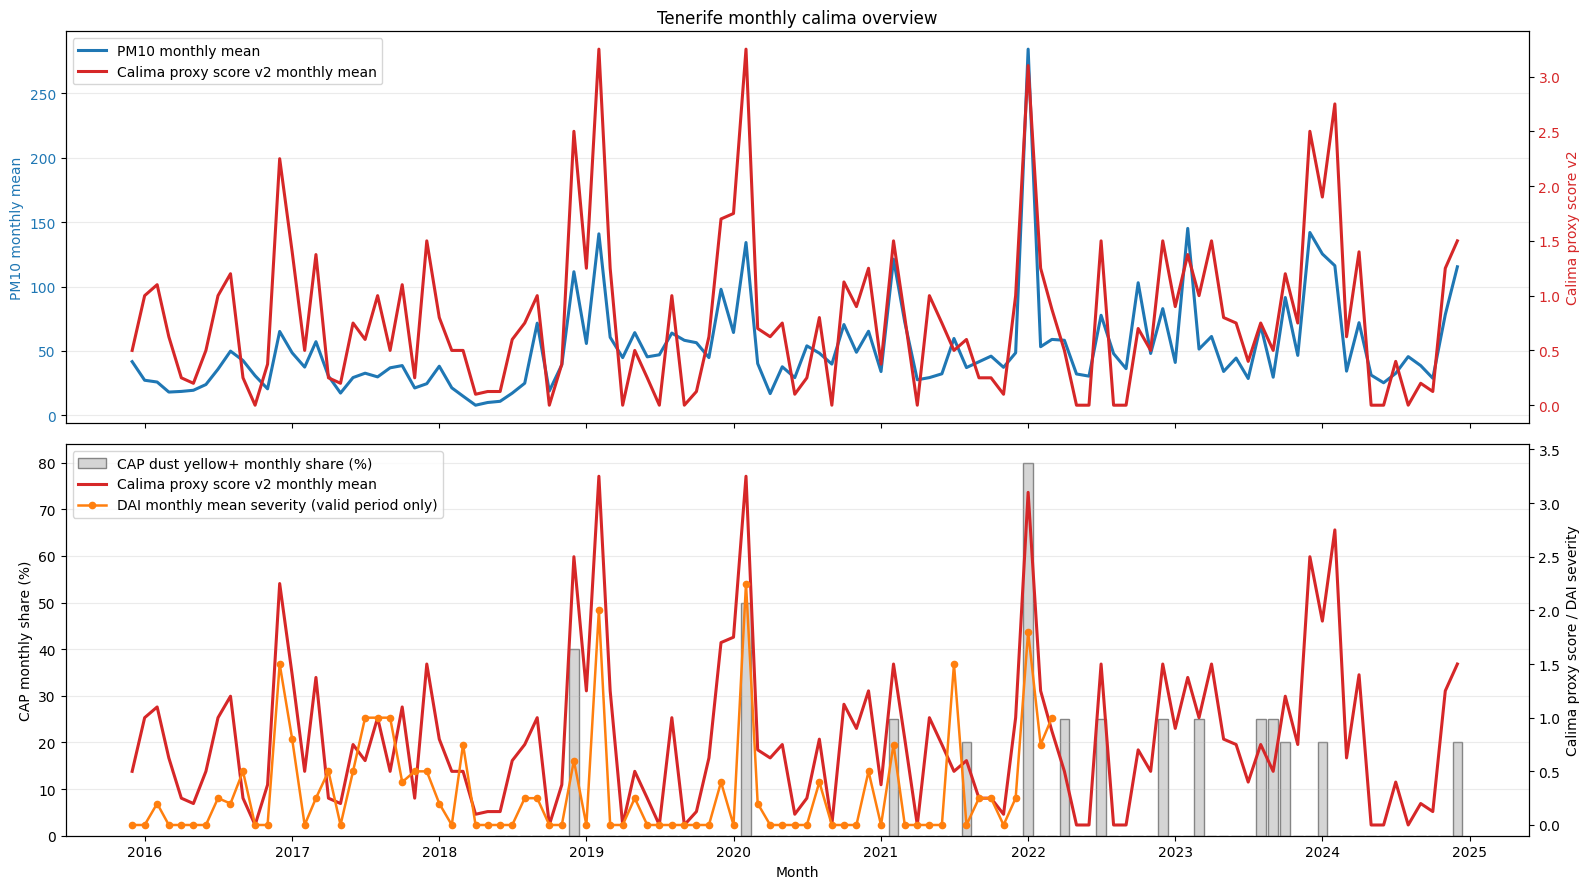

Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\calima\tfe_monthly_calima_overview_2panels_v3.png


In [50]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# LOAD
# =========================================================

fp = Path(r"C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2015_2024_v2.parquet")
df = pd.read_parquet(fp).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# =========================================================
# DAI valid period only
# =========================================================

dai_end = pd.Timestamp("2022-03-18")
df["calima_dai_flag_valid"] = df["calima_dai_flag"]
df.loc[df["week_start"] > dai_end, "calima_dai_flag_valid"] = pd.NA

dai_map = {
    "blue": 0,
    "green": 1,
    "yellow": 2,
    "red": 3,
}
df["dai_severity"] = df["calima_dai_flag_valid"].map(dai_map)

# =========================================================
# MONTHLY AGGREGATION
# =========================================================

df["month"] = df["week_start"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby("month", as_index=False)
      .agg(
          pm10_mean_month=("PM10", "mean"),
          calima_score_mean_month=("calima_proxy_score_v2", "mean"),
          cap_share_month=("cap_dust_yellow_plus_week", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
          dai_mean_month=("dai_severity", lambda s: s.dropna().mean() if s.notna().any() else np.nan),
          n_weeks=("week_start", "size")
      )
)

monthly["cap_share_pct"] = monthly["cap_share_month"] * 100

# =========================================================
# PLOT: 2 PANELS
# =========================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.2]}
)

# -------------------------
# PANEL 1: PM10 + CALIMA
# -------------------------

ax1.plot(
    monthly["month"],
    monthly["pm10_mean_month"],
    color="tab:blue",
    linewidth=2.2,
    label="PM10 monthly mean"
)
ax1.set_ylabel("PM10 monthly mean", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, axis="y", alpha=0.25)

ax1b = ax1.twinx()
ax1b.plot(
    monthly["month"],
    monthly["calima_score_mean_month"],
    color="tab:red",
    linewidth=2.2,
    label="Calima proxy score v2 monthly mean"
)
ax1b.set_ylabel("Calima proxy score v2", color="tab:red")
ax1b.tick_params(axis="y", labelcolor="tab:red")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
ax1.set_title("Tenerife monthly calima overview")

# -------------------------
# PANEL 2: CALIMA + CAP + DAI
# -------------------------

# CAP bars on left axis
ax2.bar(
    monthly["month"],
    monthly["cap_share_pct"],
    width=24,
    color="lightgray",
    edgecolor="gray",
    alpha=0.95,
    label="CAP dust yellow+ monthly share (%)"
)
ax2.set_ylabel("CAP monthly share (%)")
ax2.grid(True, axis="y", alpha=0.25)

# Right axis for calima score + DAI
ax2b = ax2.twinx()

ax2b.plot(
    monthly["month"],
    monthly["calima_score_mean_month"],
    color="tab:red",
    linewidth=2.2,
    label="Calima proxy score v2 monthly mean"
)

ax2b.plot(
    monthly["month"],
    monthly["dai_mean_month"],
    color="tab:orange",
    marker="o",
    linewidth=1.8,
    markersize=4.5,
    label="DAI monthly mean severity (valid period only)"
)

ax2b.set_ylabel("Calima proxy score / DAI severity")
ax2b.tick_params(axis="y")
ax2b.set_ylim(-0.1, max(3.2, monthly["calima_score_mean_month"].max() + 0.3))

h3, l3 = ax2.get_legend_handles_labels()
h4, l4 = ax2b.get_legend_handles_labels()
ax2.legend(h3 + h4, l3 + l4, loc="upper left")

# -------------------------
# X axis formatting
# -------------------------

ax2.set_xlabel("Month")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

out_dir = Path(r"C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\calima")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_monthly_calima_overview_2panels_v3.png"
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp)